In [4]:
##IMPORTING LIBRARIES
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.linalg import inv
import matplotlib.pyplot as plt

| Variable   | Parameter                                 | Value  | Unit         |
|------------|------------------------------------------|--------|--------------|
| $m_{c}$    | The mass of the cart                     | 0.360  | $Kg$         |
| $m_{p}$    | The mass of the pendulum rod             | 0.179  | $Kg$         |
| $\ell$     | The length of the pendulum rod           | 0.463  | $m$          |
| $g$        | The acceleration due to gravity          | 9.810  | $m/s^2$      |
| $\mu_{c}$  | The friction coefficient between the cart and the guiderail | 0.004  | $N/m/s$      |
| $\mu_{p}$  | Pendulum damping coefficient             | 0.001  | $N/m/s$      |
| $\jmath$   | The rotary inertia of the pendulum rod   | 0.013  | $kg \, m^2$  |

O fator de decaimento ($\lambda$) é a razão entre amplitudes sucessivas de uma oscilação amortecida. Ele indica o quanto a amplitude do movimento diminui de um ciclo para o próximo devido à dissipação de energia (como atrito viscoso).

#### Definição Matemática
Seja $\theta_{n}$ a amplitude do movimento no $n$-ésimo ciclo e $\theta_{n+1}$ a amplitude no próximo ciclo, então o fator de decaimento é:

$$\lambda = \frac{\theta_{n+1}}{\theta_{n}}$$

Onde:
* $\lambda$ é adimensional e assume valores entre $0$ e $1$.
* Quanto menor $\lambda$, maior a dissipação de energia a cada oscilação.
* Se $\lambda = 1$, não há amortecimento (movimento perpétuo).
* Se $\lambda = 0.5$, a amplitude cai para metade a cada ciclo.

#### Relação com o Coeficiente de Amortecimento $\gamma$


O fator de decaimento está relacionado à taxa de amortecimento $\gamma$ pela equação:

$$\gamma = -\frac{\ln(\lambda)}{T} $$
Onde:
* $T$ é o período da oscilação amortecida (tempo para um ciclo completo).

Se conhecemos $\gamma$ e $T$, podemos calcular $\gamma$, e a partir dele, o coeficiente de atrito viscoso $b$:

$$b = 2I \gamma$$

O momento de inércia ($I$) do pêndulo invertido depende do ponto de rotação e da distribuição de massa do sistema. Normalmente, um pêndulo invertido é modelado como uma haste delgada de comprimento $L$ e massa $m$, pivotada em uma extremidade. Se houver um peso concentrado na extremidade, o cálculo pode mudar.
Aqui estão os casos mais comuns:

#### Haste Delgada Pivotada em uma Extremidade
Se o pêndulo invertido for apenas uma haste homogênea, o momento de inércia em relação ao ponto de rotação (extremidade superior) é dado por:

$$I = \frac{1}{3} m_h L^2$$


#### Massa Concentrada na Extremidade da Haste
Se houver uma partícula de massa $m_p$ na extremidade da haste (considerando a haste de massa desprezível ou muito menor que $m_p$), o momento de inércia será:

$$I = m_p L^2$$

#### Haste Delgada + Massa na Extremidade
Se o pêndulo for composto por uma haste de massa $m_h$ e uma partícula de massa $m_p$ na extremidade, o momento de inércia total será a soma dos dois casos anteriores:

$$I = \frac{1}{3} m_h L^2 + m_p L^2$$

#### Modelo de Atrito Viscoso
O atrito viscoso atua como uma força proporcional à velocidade:
$$ b = \frac{m_c a}{v} $$

O Que Precisamos Medir
* $m_c$ Massa do carro (kg)

* $a$ Aceleração do carro (m/s²) (pode ser calculada a partir da velocidade)

* $v$ Velocidade do carro (m/s) em diferentes instantes

Como Calcular $a$ a partir dos Dados?
Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.

## 15/Feb/25 
### 14:42

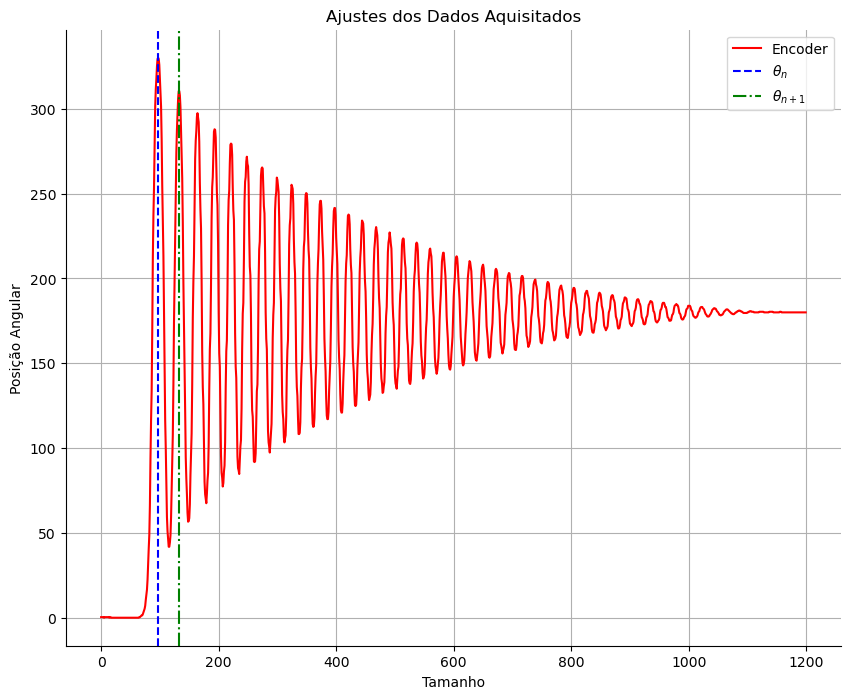

In [253]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.plot(n,(dataset['x1'])*(360/1024), color='r', label='Encoder')
plt.title("Ajustes dos Dados Aquisitados")
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.axvline(x=n[97], color='b', linestyle='--', label=r'$\theta_{n}$')   
plt.axvline(x=n[133], color='g', linestyle='-.', label=r'$\theta_{n+1}$')  
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

$$\lambda = \frac{\theta_{n+1}}{\theta_{n}}$$

$\theta_{n+1} = 937$

$\theta_{n+1} = 883$

$T = 36$

$$\lambda = 0.9403620873269436$$

In [188]:
lamb = 0.9403620873269436
T = 36 * .05

$$\gamma = -\frac{\ln(\lambda)}{T} $$

In [191]:
gamma = -np.log(lamb)/T
gamma

0.03416126589127936

$$I = \frac{1}{3} m_h L^2$$

$m_h=0.179$ $kg$

$L=0.463$ $m$

In [194]:
m_h = 0.179
L = 0.463
I = 1/3 * m_h * L**2
round(I,3)

0.013

$$b = 2I \gamma$$

In [197]:
b = 2*I*gamma
round(b,3)

0.001

## 15/Feb/25 
### 15:45

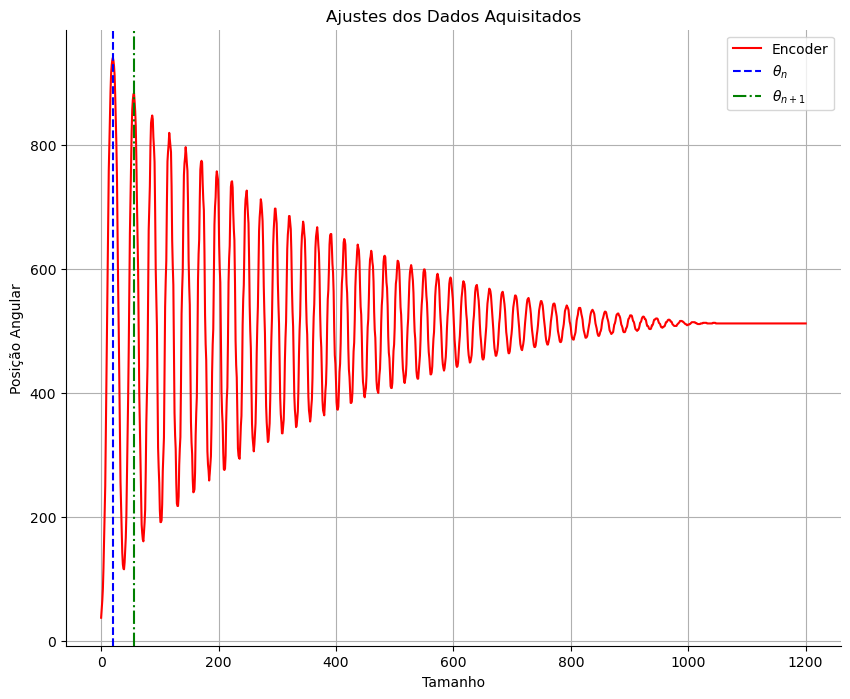

In [204]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.plot(n,dataset['x1'], color='r', label='Encoder')
plt.title("Ajustes dos Dados Aquisitados")
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.axvline(x=n[20], color='b', linestyle='--', label=r'$\theta_{n}$')   
plt.axvline(x=n[56], color='g', linestyle='-.', label=r'$\theta_{n+1}$')  
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

$$\lambda = \frac{\theta_{n+1}}{\theta_{n}}$$

$\theta_{n+1} = 937$

$\theta_{n+1} = 883$

$T = 1.8$

$$\lambda = 0.9393617021276596$$


In [207]:
lamb = 0.9393617021276596
T = 36 * .05

$$\gamma = -\frac{\ln(\lambda)}{T} $$

In [210]:
gamma = -np.log(lamb)/T
gamma

0.03475259703338309

$$I = \frac{1}{3} m_h L^2$$

$m_h=0.179$ $kg$

$L=0.463$ $m$

In [213]:
m_h = 0.179
L = 0.463
I = 1/3 * m_h * L**2
round(I,3)

0.013

$$b = 2I \gamma$$

In [216]:
b = 2*I*gamma
round(b,3)

0.001

## 15/Feb/25 
### 15:54

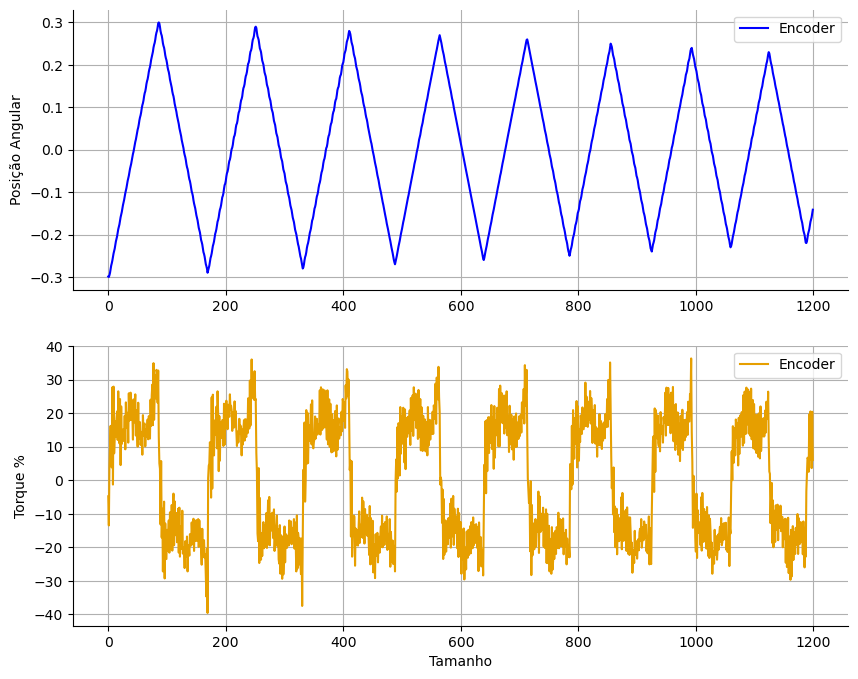

In [104]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.subplot(211)
plt.plot(n,dataset['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,dataset['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

        x1   x3     u     Error  RealTime  SimulateTime
86  3908.0  0.3  13.0 -0.012036  4.337964          4.35
Max:  86


       x1   x3     u     Error  RealTime  SimulateTime
1  3908.0 -0.3 -13.5 -0.001211  0.098789           0.1
Min:  1


        x1      x3     u     Error  RealTime  SimulateTime
0   3908.0 -0.3000 -13.5 -0.001211  0.098789          0.10
1   3908.0 -0.2958   3.8 -0.009694  0.140306          0.15
2   3908.0 -0.2901  10.2  0.001123  0.201123          0.20
3   3908.0 -0.2813  16.2  0.010198  0.260198          0.25
4   3908.0 -0.2731   6.8 -0.003293  0.296707          0.30
..     ...     ...   ...       ...       ...           ...
81  3908.0  0.2759  32.9 -0.011588  4.138412          4.15
82  3908.0  0.2804  32.3 -0.008314  4.191686          4.20
83  3908.0  0.2881  23.1  0.011681  4.261681          4.25
84  3908.0  0.2980  32.7  0.007147  4.307147          4.30
85  3908.0  0.3000  13.0 -0.012036  4.337964          4.35

[86 rows x 6 columns]

 
 
 



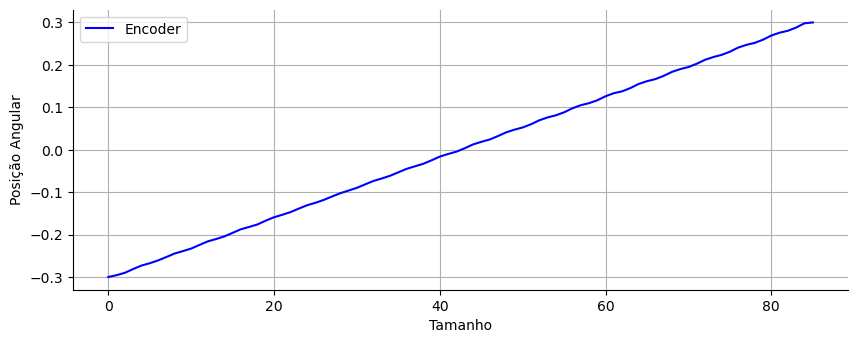

In [106]:
print(dataset[(dataset["x3"] >= max(dataset['x3']))])
indices_max = dataset[dataset['x3'] == dataset['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(dataset[(dataset["x3"] <= min(dataset['x3']))])
indices_min = dataset[dataset['x3'] == dataset['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
dataset.index = dataset.index.astype(int)  # Converte o índice para inteiro
df = dataset[(dataset.index >= int(indices_min[0])) & (dataset.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [109]:
v_i = df["x3"][19]-df["x3"][0]
v_f = df["x3"][len(df)-1]-df["x3"][len(df)-21]
t_i = 0
t_f = len(df)*.05
a = (v_f-v_i)/(t_f-t_i)

m_c = .330

b1 = (a*m_c)/v_i
print("\n Valor tabela:",round(b1,3),"\n")
print("\n Valor real:",b1,"\n")


 Valor tabela: 0.003 


 Valor real: 0.0032362006164191616 



## 15/Feb/25
### 16:04

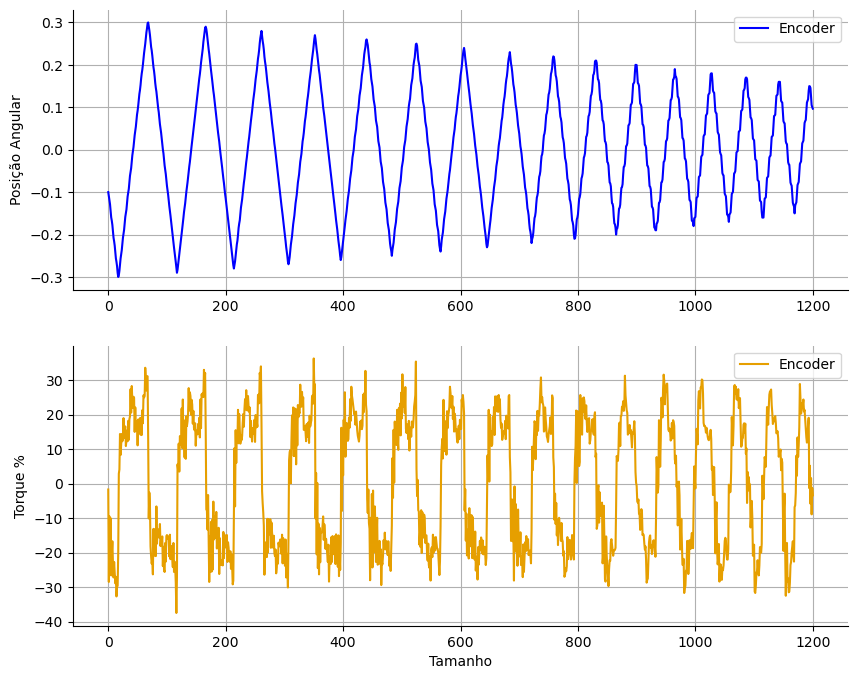

In [115]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.subplot(211)
plt.plot(n,dataset['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,dataset['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

        x1   x3     u     Error  RealTime  SimulateTime
68  3908.0  0.3  12.7  0.006433  3.456433          3.45
Max:  68


        x1   x3     u     Error  RealTime  SimulateTime
17  3908.0 -0.3 -19.8 -0.001328  0.898672           0.9
Min:  17


        x1      x3     u     Error  RealTime  SimulateTime
0   3908.0 -0.3000 -19.8 -0.001328  0.898672          0.90
1   3908.0 -0.2955   2.9 -0.009690  0.940310          0.95
2   3908.0 -0.2854   4.1  0.002282  1.002282          1.00
3   3908.0 -0.2706  14.4  0.008146  1.058146          1.05
4   3908.0 -0.2564   8.3 -0.000649  1.099351          1.10
5   3908.0 -0.2469  11.3 -0.009216  1.140784          1.15
6   3908.0 -0.2368  14.4  0.000250  1.200250          1.20
7   3908.0 -0.2223  12.3  0.010296  1.260296          1.25
8   3908.0 -0.2077  13.0 -0.001242  1.298758          1.30
9   3908.0 -0.1984  19.0 -0.011687  1.338313          1.35
10  3908.0 -0.1885  13.2  0.002953  1.402953          1.40
11  3908.0 -0.1732  15.3  0.012487  1.462487  

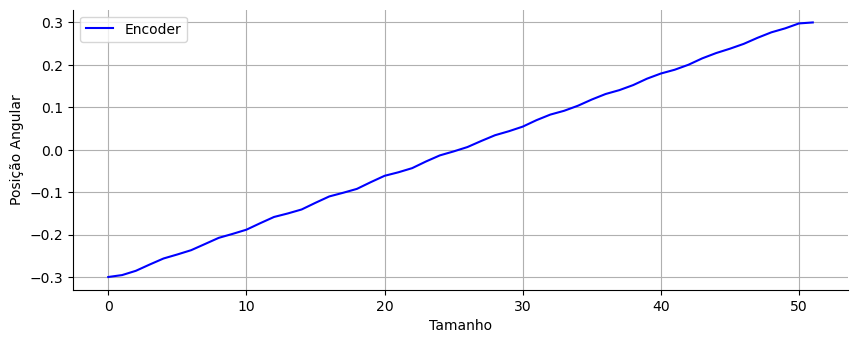

In [118]:
print(dataset[(dataset["x3"] >= max(dataset['x3']))])
indices_max = dataset[dataset['x3'] == dataset['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(dataset[(dataset["x3"] <= min(dataset['x3']))])
indices_min = dataset[dataset['x3'] == dataset['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
dataset.index = dataset.index.astype(int)  # Converte o índice para inteiro
df = dataset[(dataset.index >= int(indices_min[0])) & (dataset.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [121]:
v_i = df["x3"][19]-df["x3"][0]
v_f = df["x3"][len(df)-1]-df["x3"][len(df)-21]
t_i = 0
t_f = len(df)*.05
a = (v_f-v_i)/(t_f-t_i)

m_c = .330

b2 = (a*m_c)/v_i
print("\n Valor tabela:",round(b2,3),"\n")
print("\n Valor real:",b2,"\n")


 Valor tabela: 0.004 


 Valor real: 0.003861641713990724 



## 15/Feb/25
### 16:12

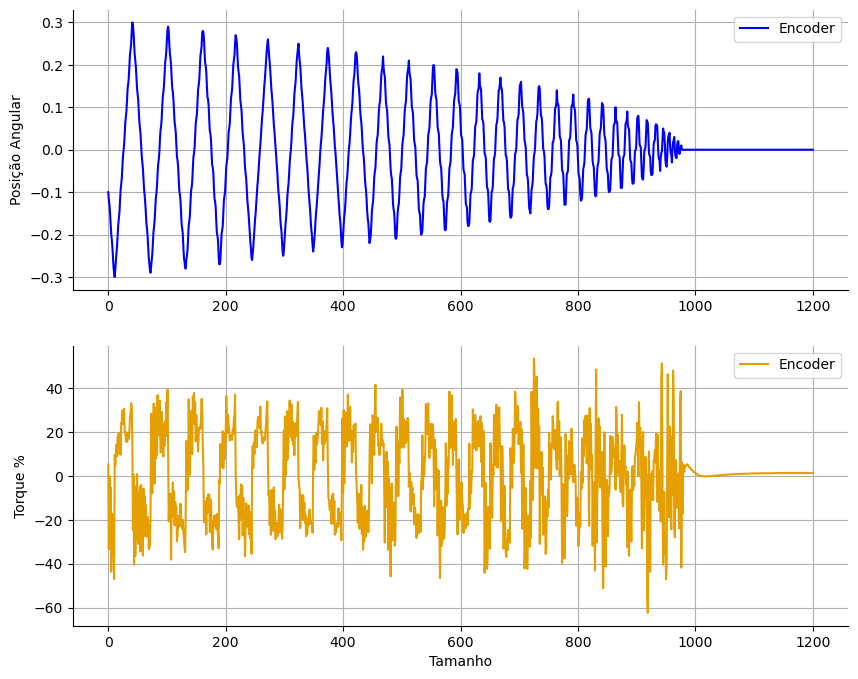

In [128]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.subplot(211)
plt.plot(n,dataset['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,dataset['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

        x1   x3     u     Error  RealTime  SimulateTime
41  3896.0  0.3  17.1 -0.005437  2.094563           2.1
Max:  41


        x1   x3    u     Error  RealTime  SimulateTime
11  3896.0 -0.3  9.5  0.003956  0.603956           0.6
Min:  11


        x1      x3     u     Error  RealTime  SimulateTime
0   3896.0 -0.3000   9.5  0.003956  0.603956          0.60
1   3896.0 -0.2806   4.7  0.007604  0.657604          0.65
2   3896.0 -0.2594  10.1 -0.002893  0.697107          0.70
3   3896.0 -0.2438  14.2 -0.009711  0.740289          0.75
4   3896.0 -0.2262   8.9  0.001726  0.801726          0.80
5   3896.0 -0.2014  17.8  0.013651  0.863651          0.85
6   3896.0 -0.1770  18.7 -0.002429  0.897571          0.90
7   3896.0 -0.1630  19.4 -0.014521  0.935479          0.95
8   3896.0 -0.1482  10.0  0.002825  1.002825          1.00
9   3896.0 -0.1214  17.3  0.014525  1.064525          1.05
10  3896.0 -0.0966   9.6 -0.002767  1.097233          1.10
11  3896.0 -0.0830  24.1 -0.013736  1.136264    

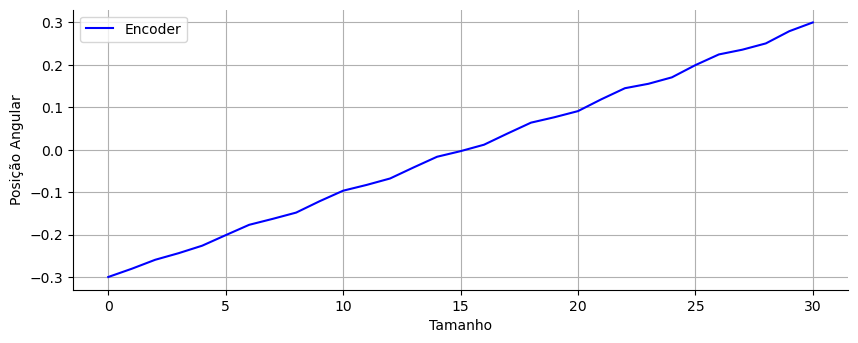

In [130]:
print(dataset[(dataset["x3"] >= max(dataset['x3']))])
indices_max = dataset[dataset['x3'] == dataset['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(dataset[(dataset["x3"] <= min(dataset['x3']))])
indices_min = dataset[dataset['x3'] == dataset['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
dataset.index = dataset.index.astype(int)  # Converte o índice para inteiro
df = dataset[(dataset.index >= int(indices_min[0])) & (dataset.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [133]:
v_i = df["x3"][19]-df["x3"][0]
v_f = df["x3"][len(df)-1]-df["x3"][len(df)-21]
t_i = 0
t_f = len(df)*.05
a = (v_f-v_i)/(t_f-t_i)

m_c = .330

b3 = (a*m_c)/v_i
print("\n Valor tabela:",round(b3,3),"\n")
print("\n Valor real:",b3,"\n")


 Valor tabela: 0.011 


 Valor real: 0.011306597228170569 



## 15/Feb/25
### 16:18

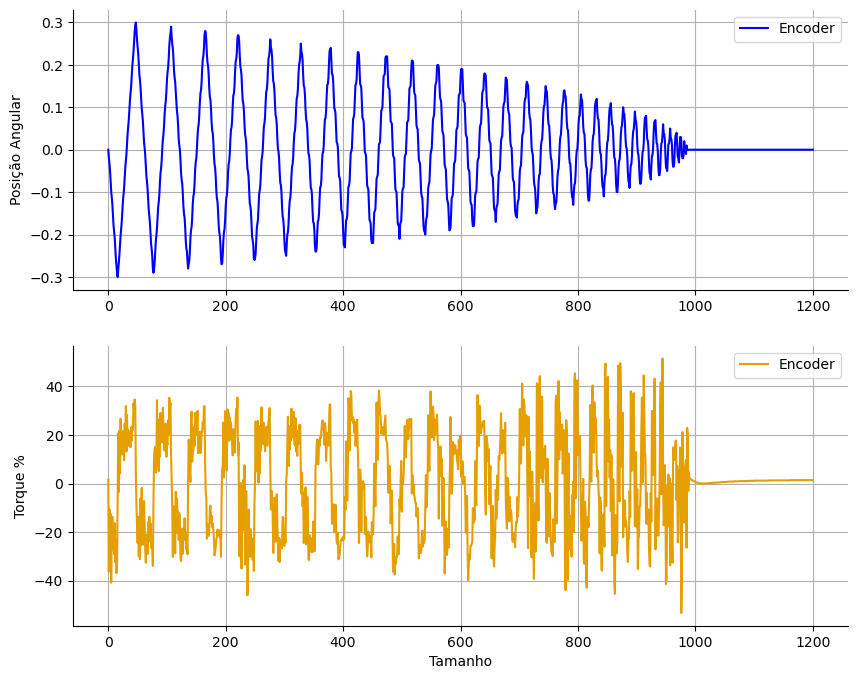

In [140]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.subplot(211)
plt.plot(n,dataset['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,dataset['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

        x1   x3    u     Error  RealTime  SimulateTime
47  3896.0  0.3  3.4  0.000984  2.400984           2.4
Max:  47


        x1   x3    u     Error  RealTime  SimulateTime
16  3896.0 -0.3 -5.4  0.009265  0.859265          0.85
Min:  16


        x1      x3     u     Error  RealTime  SimulateTime
0   3896.0 -0.3000  -5.4  0.009265  0.859265          0.85
1   3896.0 -0.2826  20.7 -0.002104  0.897896          0.90
2   3896.0 -0.2666  -3.5 -0.006285  0.943715          0.95
3   3896.0 -0.2486  21.6  0.000388  1.000388          1.00
4   3896.0 -0.2254   4.1  0.008425  1.058425          1.05
5   3896.0 -0.2022  26.7 -0.001475  1.098525          1.10
6   3896.0 -0.1866  16.0 -0.009212  1.140788          1.15
7   3896.0 -0.1698  14.4  0.002407  1.202407          1.20
8   3896.0 -0.1446  11.9  0.009319  1.259319          1.25
9   3896.0 -0.1218  21.4 -0.002240  1.297760          1.30
10  3896.0 -0.1066  21.7 -0.009735  1.340265          1.35
11  3896.0 -0.0898   9.6  0.002609  1.402609      

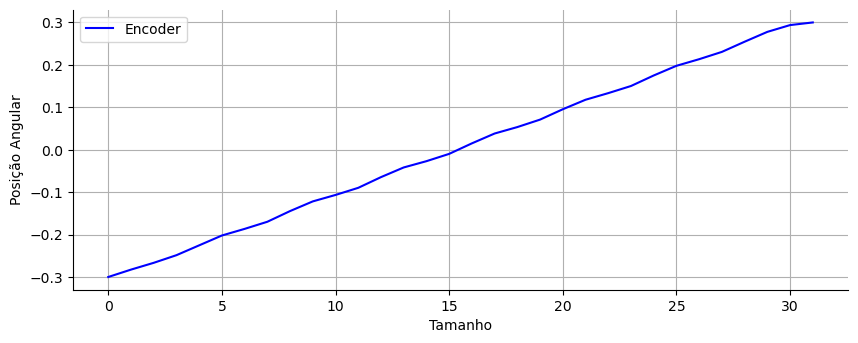

In [142]:
print(dataset[(dataset["x3"] >= max(dataset['x3']))])
indices_max = dataset[dataset['x3'] == dataset['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(dataset[(dataset["x3"] <= min(dataset['x3']))])
indices_min = dataset[dataset['x3'] == dataset['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
dataset.index = dataset.index.astype(int)  # Converte o índice para inteiro
df = dataset[(dataset.index >= int(indices_min[0])) & (dataset.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [145]:
v_i = df["x3"][19]-df["x3"][0]
v_f = df["x3"][len(df)-1]-df["x3"][len(df)-21]
t_i = 0
t_f = len(df)*.05
a = (v_f-v_i)/(t_f-t_i)

m_c = .330

b4 = (a*m_c)/v_i
print("\n Valor tabela:",round(b4,3),"\n")
print("\n Valor real:",b4,"\n")


 Valor tabela: 0.01 


 Valor real: 0.010451482479784358 



## 15/Feb/25
### 16:20

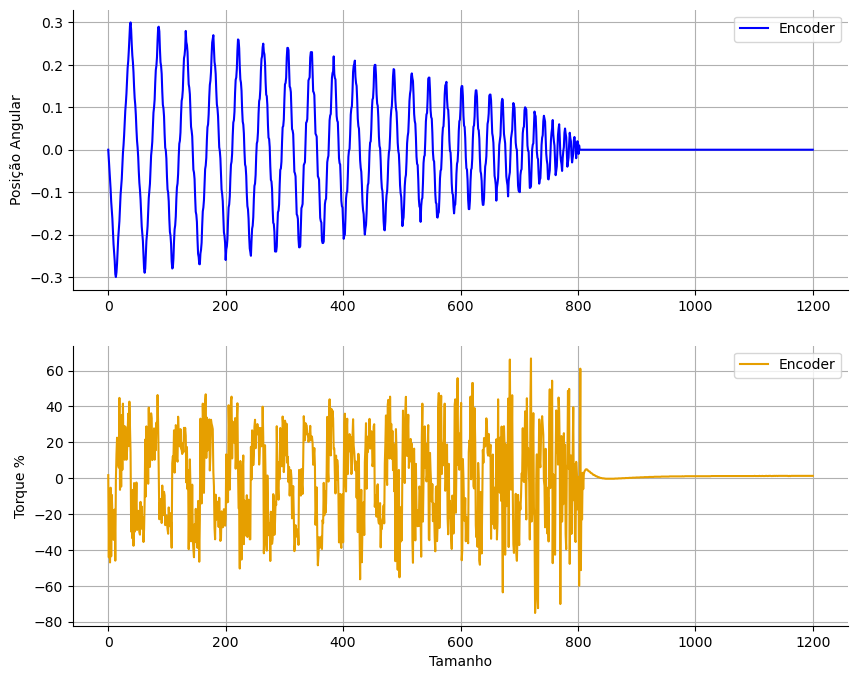

In [152]:
plt.figure(figsize=(10,8))
n=np.arange(0,len(dataset),1)
plt.subplot(211)
plt.plot(n,dataset['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,dataset['u'], color='#E69F00', label='Encoder')
plt.ylabel("Torque %")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

        x1   x3     u     Error  RealTime  SimulateTime
38  3896.0  0.3  14.5 -0.010014  1.939986          1.95
Max:  38


        x1   x3    u    Error  RealTime  SimulateTime
13  3896.0 -0.3 -0.8 -0.00193   0.69807           0.7
Min:  13


        x1      x3     u     Error  RealTime  SimulateTime
0   3896.0 -0.3000  -0.8 -0.001930  0.698070          0.70
1   3896.0 -0.2888  13.3 -0.010555  0.739445          0.75
2   3896.0 -0.2678  22.6  0.001683  0.801683          0.80
3   3896.0 -0.2368  14.3  0.010551  0.860551          0.85
4   3896.0 -0.2073   8.1 -0.001397  0.898603          0.90
5   3896.0 -0.1883   5.9 -0.011699  0.938301          0.95
6   3896.0 -0.1683  44.8  0.001773  1.001773          1.00
7   3896.0 -0.1368  -6.5  0.012695  1.062695          1.05
8   3896.0 -0.1058  29.0 -0.002374  1.097626          1.10
9   3896.0 -0.0888  -4.7 -0.012874  1.137126          1.15
10  3896.0 -0.0688  35.2  0.004011  1.204011          1.20
11  3896.0 -0.0358   4.7  0.010143  1.260143      

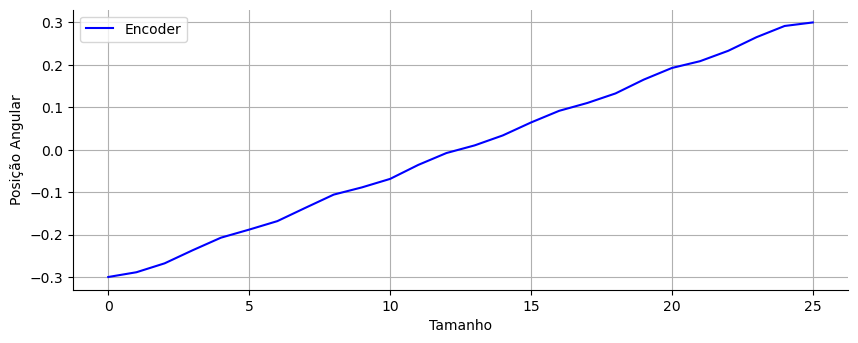

In [154]:
print(dataset[(dataset["x3"] >= max(dataset['x3']))])
indices_max = dataset[dataset['x3'] == dataset['x3'].max()].index.tolist()
print("Max: ",indices_max[0])
print("\n")
print(dataset[(dataset["x3"] <= min(dataset['x3']))])
indices_min = dataset[dataset['x3'] == dataset['x3'].min()].index.tolist()
print("Min: ",indices_min[0])
print("\n")
dataset.index = dataset.index.astype(int)  # Converte o índice para inteiro
df = dataset[(dataset.index >= int(indices_min[0])) & (dataset.index <= int(indices_max[0]))]
df = df.reset_index(drop=True)
print(df)
print("\n \n \n \n")
plt.figure(figsize=(10,8))
n=np.arange(0,len(df),1)
plt.subplot(211)
plt.plot(n,df['x3'], color='b', label='Encoder')
plt.ylabel("Posição Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()

Se tivermos um dataset com tempo e velocidade, podemos calcular a aceleração como:

$$ a =\frac{\Delta v}{\Delta t}$$
  
Ou seja:

$$ a =\frac{v_f - v_i}{t_f - t_i}$$

Então podemos calcular $b$ para cada ponto e obter uma média.
$$ b = \frac{m_c a}{v} $$

In [157]:
v_i = df["x3"][19]-df["x3"][0]
v_f = df["x3"][len(df)-1]-df["x3"][len(df)-21]
t_i = 0
t_f = len(df)*.05
a = (v_f-v_i)/(t_f-t_i)

m_c = .330

b5 = (a*m_c)/v_i
print("\n Valor tabela:",round(b5,3),"\n")
print("\n Valor real:",b5,"\n")


 Valor tabela: 0.013 


 Valor real: 0.012605000330709677 



Se você obteve valores diferentes para o coeficiente de atrito viscoso ($b$) em diferentes simulações:
$$ b=0.003,0.004,0.011,0.011,0.013$$

significa que o sistema pode estar sofrendo variações devido a diferentes fatores, como erros experimentais, variações de atrito no trilho ou comportamento não puramente linear.

Como Analisar os Resultados?

1️⃣ Cálculo da Média e Desvio Padrão
Para entender a variabilidade dos valores, podemos calcular a média e o desvio padrão:

$$b_{medio} = \frac{0.003+0.004+0.011+0.011+0.013}{5} = 0.008$$

$$ \sigma = \sqrt{}$$
Isso ajudará a entender se há um padrão ou se os valores estão muito dispersos.

In [176]:
b_med = (b1+b2+b3+b4+b5)/5
b_med
mu_c = (((b1-b_med)**2+(b2-b_med)**2+(b3-b_med)**2+(b4-b_med)**2+(b5-b_med)**2)/5)**(1/2)
print("\n mu_c Valor Tabela:",round(mu_c ,3),"\n")
print("\n mu_c Valor Real:",mu_c ,"\n")


 mu_c Valor Tabela: 0.004 


 mu_c Valor Real: 0.003938078583790972 



Valor chat mu_c = 0.005